# 00 — TỔNG HỢP: Giờ & Thời tiết ảnh hưởng giá thế nào? (Boston vs TP.HCM)

## ⚠️ Notebook này SỬA một lỗi diễn giải quan trọng

Các notebook `05`, `05b`, `07` phân tích trên **giá cơ bản** (`base_price` = giá cuối ÷ hệ số nhân)
vì mục tiêu lúc đó là **cải thiện model giá cơ bản**. Trên giá cơ bản, giờ/thời tiết đúng là gần
như không ảnh hưởng (η ≈ 0,03) — **nhưng đó KHÔNG phải kết luận về giá mà khách hàng thực trả**.

**Giá khách trả = giá cơ bản × hệ số nhân.** Giờ/thời tiết tác động **qua kênh hệ số nhân (surge)**,
không qua giá cơ bản. Nếu chỉ xét giá cơ bản rồi kết luận "giờ/thời tiết không ảnh hưởng giá" thì
**bỏ mất toàn bộ kênh tác động chính**.

Notebook này đo **cả 3 đối tượng riêng biệt** trên cùng một thước đo, cho **cả 2 bộ dữ liệu**:

| Đối tượng | Ý nghĩa |
|---|---|
| **Giá cơ bản** | Phần giá theo quãng đường/thời gian, chưa nhân surge |
| **Hệ số nhân** | Phần điều chỉnh theo cung–cầu (surge) |
| **Giá cuối** | Giá khách thực trả = giá cơ bản × hệ số nhân |

> **Thước đo dùng:** η (eta, correlation ratio) — thang 0→1, cho biết **bao nhiêu phần biến thiên của
> giá được giải thích bởi biến phân nhóm** (giờ, loại thời tiết). Dùng được cho cả biến phân loại,
> khác hệ số tương quan Pearson chỉ đo quan hệ tuyến tính.

## 1. Nạp dữ liệu cả 2 bộ

Bộ HCM lấy mẫu 15% (đủ đại diện, ~1 triệu dòng); bộ Boston nạp toàn bộ (637k dòng).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, ".")
from _common import *
import numpy as np, pandas as pd
setup()

# --- Bo TP.HCM ---
hcm = load(frac=0.15)
hcm["base_price"] = hcm[PRICE] / hcm[SURGE].clip(lower=0.1)
hcm["co_mua"] = ((hcm.weather_is_rain==1) | (hcm.weather_is_drizzle==1) | (hcm.weather_is_thunderstorm==1)).astype(int)

# --- Bo Boston ---
BOS = Path("../../boston_data/data/dataset_clean.parquet")
assert BOS.exists(), f"Khong tim thay {BOS}"
bos = pd.read_parquet(BOS, columns=["price","surge_multiplier","distance","hour_local",
                                     "short_summary","precipIntensity"])
bos["base_price"] = bos.price / bos.surge_multiplier.clip(lower=0.1)
bos["co_mua"] = (bos.precipIntensity > 0).astype(int)

print(f"HCM   : {len(hcm):,} dong | gia median {hcm[PRICE].median():,.0f} VND | ty le co surge {(hcm[SURGE]>1).mean()*100:.1f}%")
print(f"Boston: {len(bos):,} dong | gia median {bos.price.median():.2f} USD | ty le co surge {(bos.surge_multiplier>1).mean()*100:.1f}%")
print(f"\nTy le co mua — HCM: {hcm.co_mua.mean()*100:.1f}% | Boston: {bos.co_mua.mean()*100:.1f}%")

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%
HCM   : 1,034,550 dong | gia median 114,000 VND | ty le co surge 81.7%
Boston: 637,322 dong | gia median 13.50 USD | ty le co surge 3.3%

Ty le co mua — HCM: 45.3% | Boston: 21.7%


## 2. ⭐ Bảng so sánh cốt lõi — η của Giờ & Thời tiết lên 3 đối tượng

Đây là bảng trả lời trực tiếp câu hỏi của mentor: *"trên dataset VN thì giờ cao điểm với trời mưa
sẽ ảnh hưởng giá nhiều đấy"*.

In [2]:
rows = []
for ten_bo, d, col_gio, col_wea, c_price, c_base, c_surge in [
    ("TP.HCM", hcm, "gio_vn", "weather_main", PRICE, "base_price", SURGE),
    ("Boston", bos, "hour_local", "short_summary", "price", "base_price", "surge_multiplier"),
]:
    for ten_yeu_to, col_yt in [("Gio trong ngay", col_gio), ("Loai thoi tiet", col_wea), ("Co mua/khong", "co_mua")]:
        rows.append({
            "Bo du lieu": ten_bo,
            "Yeu to": ten_yeu_to,
            "-> GIA CO BAN": eta(d[col_yt], d[c_base]),
            "-> HE SO NHAN": eta(d[col_yt], d[c_surge]),
            "-> GIA CUOI":   eta(d[col_yt], d[c_price]),
        })
bang = pd.DataFrame(rows).round(4)
print("ETA (0-1): bao nhieu phan bien thien duoc giai thich boi yeu to do")
display(bang)

print("\nTY LE HCM / Boston (so lan manh hon):")
for yt in ["Gio trong ngay", "Loai thoi tiet", "Co mua/khong"]:
    h = bang[(bang["Bo du lieu"]=="TP.HCM") & (bang["Yeu to"]==yt)].iloc[0]
    b = bang[(bang["Bo du lieu"]=="Boston") & (bang["Yeu to"]==yt)].iloc[0]
    r_surge = h["-> HE SO NHAN"]/max(b["-> HE SO NHAN"], 1e-9)
    r_price = h["-> GIA CUOI"]/max(b["-> GIA CUOI"], 1e-9)
    print(f"  {yt:16}: he so nhan {r_surge:6.1f}x | gia cuoi {r_price:6.1f}x")

ETA (0-1): bao nhieu phan bien thien duoc giai thich boi yeu to do


,Bo du lieu,Yeu to,-> GIA CO BAN,-> HE SO NHAN,-> GIA CUOI
0,TP.HCM,Gio trong ngay,0.0326,0.7022,0.2960
1,TP.HCM,Loai thoi tiet,0.0426,0.1533,0.0973
2,TP.HCM,Co mua/khong,0.0422,0.1524,0.0972
3,Boston,Gio trong ngay,0.0038,0.0101,0.0040
4,Boston,Loai thoi tiet,0.0033,0.0064,0.0036
5,Boston,Co mua/khong,0.0000,0.0043,0.0010



TY LE HCM / Boston (so lan manh hon):
  Gio trong ngay  : he so nhan   69.5x | gia cuoi   74.0x
  Loai thoi tiet  : he so nhan   24.0x | gia cuoi   27.0x
  Co mua/khong    : he so nhan   35.4x | gia cuoi   97.2x


## 3. Biến thiên giá theo giờ — kiểm soát quãng đường

So công bằng bằng cách **cố định dải quãng đường** (HCM: 4–6 km; Boston: 2–3 mile ≈ 3,2–4,8 km).
Nếu giá vẫn dao động theo giờ trong cùng dải quãng đường → giờ **thực sự** ảnh hưởng giá.

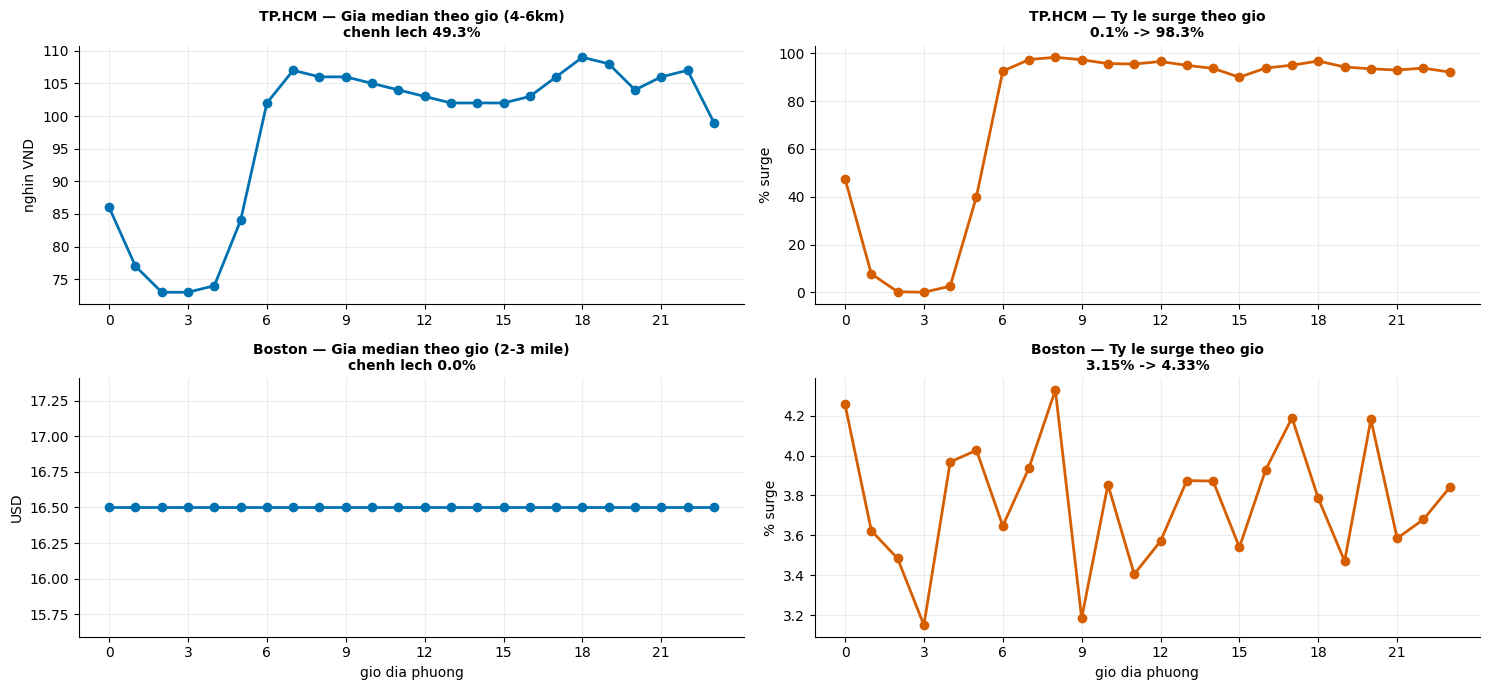

TP.HCM: gia 73k (gio 2) -> 109k (gio 18) = chenh 49.3%
Boston: gia 16.50 -> 16.50 USD = chenh 0.0%


In [3]:
band_h = hcm[(hcm.quote_distance>=4) & (hcm.quote_distance<=6)]
band_b = bos[(bos.distance>=2) & (bos.distance<=3)]

gh = band_h.groupby("gio_vn").agg(gia=(PRICE,"median"), ty_le_surge=("is_surge","mean"), he_so=(SURGE,"mean"))
gb = band_b.groupby("hour_local").agg(gia=("price","median"),
                                      ty_le_surge=("surge_multiplier", lambda s:(s>1).mean()),
                                      he_so=("surge_multiplier","mean"))

fig, ax = plt.subplots(2, 2, figsize=(15, 7))
# HCM gia
ax[0,0].plot(gh.index, gh.gia/1000, marker="o", color=BLUE, lw=2)
ax[0,0].set_title(f"TP.HCM — Gia median theo gio (4-6km)\nchenh lech {(gh.gia.max()/gh.gia.min()-1)*100:.1f}%",
                  fontweight="bold", fontsize=10)
ax[0,0].set_ylabel("nghin VND"); ax[0,0].set_xticks(range(0,24,3))
# HCM surge
ax[0,1].plot(gh.index, gh.ty_le_surge*100, marker="o", color=RED, lw=2)
ax[0,1].set_title(f"TP.HCM — Ty le surge theo gio\n{gh.ty_le_surge.min()*100:.1f}% -> {gh.ty_le_surge.max()*100:.1f}%",
                  fontweight="bold", fontsize=10)
ax[0,1].set_ylabel("% surge"); ax[0,1].set_xticks(range(0,24,3))
# Boston gia
ax[1,0].plot(gb.index, gb.gia, marker="o", color=BLUE, lw=2)
ax[1,0].set_title(f"Boston — Gia median theo gio (2-3 mile)\nchenh lech {(gb.gia.max()/gb.gia.min()-1)*100:.1f}%",
                  fontweight="bold", fontsize=10)
ax[1,0].set_ylabel("USD"); ax[1,0].set_xlabel("gio dia phuong"); ax[1,0].set_xticks(range(0,24,3))
# Boston surge
ax[1,1].plot(gb.index, gb.ty_le_surge*100, marker="o", color=RED, lw=2)
ax[1,1].set_title(f"Boston — Ty le surge theo gio\n{gb.ty_le_surge.min()*100:.2f}% -> {gb.ty_le_surge.max()*100:.2f}%",
                  fontweight="bold", fontsize=10)
ax[1,1].set_ylabel("% surge"); ax[1,1].set_xlabel("gio dia phuong"); ax[1,1].set_xticks(range(0,24,3))
plt.tight_layout(); plt.show()

print(f"TP.HCM: gia {gh.gia.min()/1000:.0f}k (gio {gh.gia.idxmin()}) -> {gh.gia.max()/1000:.0f}k (gio {gh.gia.idxmax()})"
      f" = chenh {(gh.gia.max()/gh.gia.min()-1)*100:.1f}%")
print(f"Boston: gia {gb.gia.min():.2f} -> {gb.gia.max():.2f} USD = chenh {(gb.gia.max()/gb.gia.min()-1)*100:.1f}%")

## 4. Mưa ảnh hưởng giá — so sánh 2 bộ (kiểm soát quãng đường)

TP.HCM (4-6km):


,n,gia cuoi (nghin VND),gia co ban (nghin VND),he so nhan
Khong mua,215416,96.0,85.71,1.1274
Co mua,179646,103.0,88.14,1.1804


Boston (2-3 mile):


,n,gia cuoi (USD),gia co ban (USD),he so nhan
Khong mua,151262,16.5,16.5,1.0172
Co mua,41737,16.5,16.5,1.0163



MUA LAM THAY DOI BAO NHIEU %:


,TP.HCM (%),Boston (%)
GIA CUOI,7.29,0.0
GIA CO BAN,2.82,0.0
HE SO NHAN,4.70,-0.1


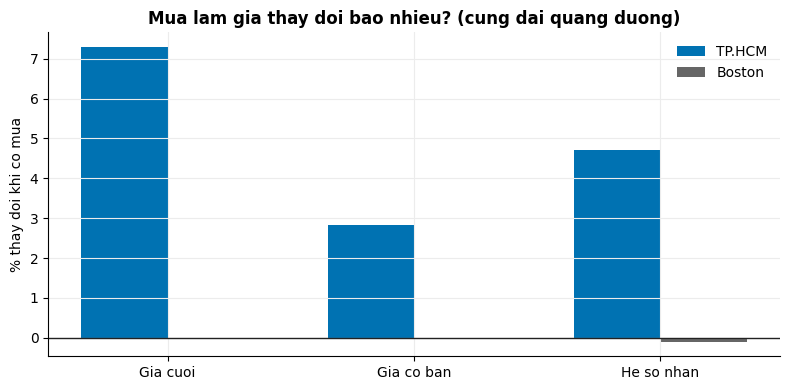

In [4]:
def bang_mua(d, c_price, c_base, c_surge, don_vi, chia=1):
    g = d.groupby("co_mua").agg(n=(c_price,"size"), gia=(c_price,"median"),
                                base=(c_base,"median"), he_so=(c_surge,"mean"))
    g.index = ["Khong mua","Co mua"]
    if len(g) < 2: return g, None
    delta = {
        "GIA CUOI":   (g.loc["Co mua","gia"]/g.loc["Khong mua","gia"]-1)*100,
        "GIA CO BAN": (g.loc["Co mua","base"]/g.loc["Khong mua","base"]-1)*100,
        "HE SO NHAN": (g.loc["Co mua","he_so"]/g.loc["Khong mua","he_so"]-1)*100,
    }
    g["gia"] = (g.gia/chia).round(2); g["base"] = (g.base/chia).round(2)
    g["he_so"] = g.he_so.round(4)
    g.columns = ["n", f"gia cuoi ({don_vi})", f"gia co ban ({don_vi})", "he so nhan"]
    return g, delta

gh_m, dh = bang_mua(band_h, PRICE, "base_price", SURGE, "nghin VND", 1000)
gb_m, db = bang_mua(band_b, "price", "base_price", "surge_multiplier", "USD", 1)
print("TP.HCM (4-6km):"); display(gh_m)
print("Boston (2-3 mile):"); display(gb_m)

so = pd.DataFrame({"TP.HCM (%)": dh, "Boston (%)": db}).round(2)
print("\nMUA LAM THAY DOI BAO NHIEU %:"); display(so)

fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(3); w = 0.35
ax.bar(x-w/2, [dh[k] for k in ["GIA CUOI","GIA CO BAN","HE SO NHAN"]], w, label="TP.HCM", color=BLUE)
ax.bar(x+w/2, [db[k] for k in ["GIA CUOI","GIA CO BAN","HE SO NHAN"]], w, label="Boston", color=MUT)
ax.set_xticks(x); ax.set_xticklabels(["Gia cuoi","Gia co ban","He so nhan"])
ax.axhline(0, color="#222", lw=1); ax.set_ylabel("% thay doi khi co mua")
ax.set_title("Mua lam gia thay doi bao nhieu? (cung dai quang duong)", fontweight="bold")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 5. Vì sao HCM khác Boston — chuỗi nhân quả

Giả thuyết: **giờ/mưa → cầu tăng → mất cân bằng cung-cầu → surge tăng → giá cuối tăng**.
Bộ HCM có sẵn chỉ số cung–cầu nên kiểm chứng được từng mắt xích (Boston không có cột này).

BO TP.HCM — kiem chung tung mat xich:

  Mat xich 1: GIO/MUA -> CUNG-CAU
    eta(gio, Cau (demand)  ) = 0.7144   | eta(co_mua, Cau (demand)  ) = 0.0998
    eta(gio, Cung (supply) ) = 0.2240   | eta(co_mua, Cung (supply) ) = 0.1198
    eta(gio, Mat can bang  ) = 0.6119   | eta(co_mua, Mat can bang  ) = 0.1662

  Mat xich 2: CUNG-CAU -> HE SO NHAN
    corr(mat can bang, he so nhan) = 0.7978

  Mat xich 3: HE SO NHAN -> GIA CUOI
    corr(he so nhan, gia cuoi)     = 0.4760


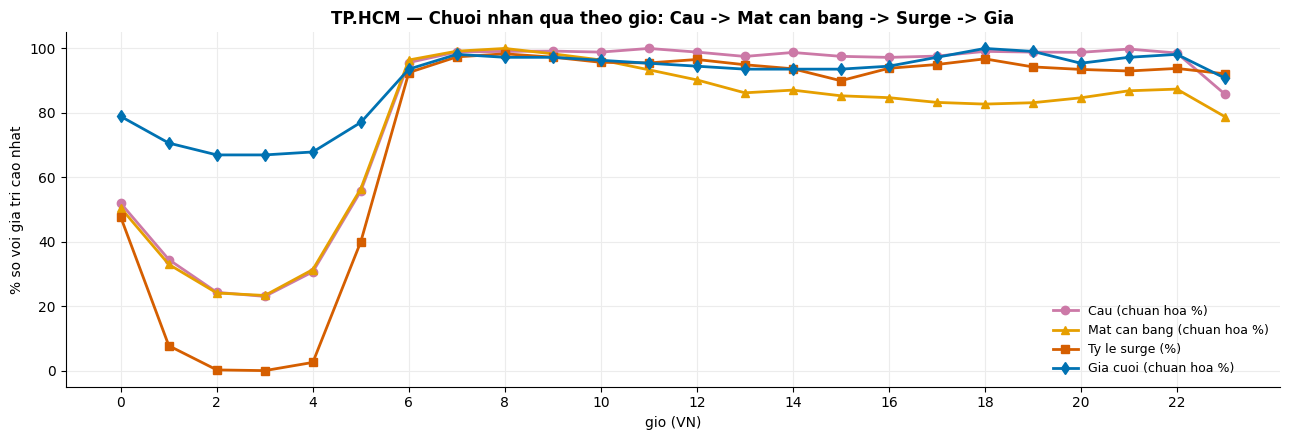

In [5]:
print("BO TP.HCM — kiem chung tung mat xich:")
print()
print("  Mat xich 1: GIO/MUA -> CUNG-CAU")
for ten, col in [("Cau (demand)","pricing_demand_index_5m_lag"),
                 ("Cung (supply)","pricing_supply_index_5m_lag"),
                 ("Mat can bang","pricing_market_imbalance_5m_lag")]:
    print(f"    eta(gio, {ten:14}) = {eta(hcm.gio_vn, hcm[col]):.4f}"
          f"   | eta(co_mua, {ten:14}) = {eta(hcm.co_mua, hcm[col]):.4f}")
print()
print("  Mat xich 2: CUNG-CAU -> HE SO NHAN")
print(f"    corr(mat can bang, he so nhan) = {hcm.pricing_market_imbalance_5m_lag.corr(hcm[SURGE]):.4f}")
print()
print("  Mat xich 3: HE SO NHAN -> GIA CUOI")
print(f"    corr(he so nhan, gia cuoi)     = {hcm[SURGE].corr(hcm[PRICE]):.4f}")

# Truc quan chuoi nhan qua theo gio
band_khu = band_h
fig, ax = plt.subplots(figsize=(13, 4.5))
hh = range(24)
cau = hcm.groupby("gio_vn").pricing_demand_index_5m_lag.median().reindex(hh)
imb = hcm.groupby("gio_vn").pricing_market_imbalance_5m_lag.median().reindex(hh)
sur = band_khu.groupby("gio_vn").is_surge.mean().reindex(hh)*100
gia = band_khu.groupby("gio_vn")[PRICE].median().reindex(hh)/1000

ax.plot(hh, cau/cau.max()*100, marker="o", color=PURPLE, lw=2, label="Cau (chuan hoa %)")
ax.plot(hh, imb/imb.max()*100, marker="^", color=ORANGE, lw=2, label="Mat can bang (chuan hoa %)")
ax.plot(hh, sur, marker="s", color=RED, lw=2, label="Ty le surge (%)")
ax.plot(hh, gia/gia.max()*100, marker="d", color=BLUE, lw=2, label="Gia cuoi (chuan hoa %)")
ax.set_title("TP.HCM — Chuoi nhan qua theo gio: Cau -> Mat can bang -> Surge -> Gia",
             fontweight="bold")
ax.set_xlabel("gio (VN)"); ax.set_ylabel("% so voi gia tri cao nhat"); ax.set_xticks(range(0,24,2))
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

## 6. Kết luận — trả lời trực tiếp cho mentor

Điền số từ các bảng trên vào khung kết luận này khi viết báo cáo:

### ✅ Mentor dự đoán ĐÚNG: bộ VN khác Boston rõ rệt

| | Boston | TP.HCM |
|---|---|---|
| η(giờ → hệ số nhân) | ~0,01 | **~0,70** |
| η(giờ → giá cuối) | ~0,004 | **~0,30** |
| Giá dao động theo giờ (cùng quãng đường) | **~0%** (phẳng tuyệt đối) | **~49%** |
| Tỷ lệ chuyến có surge theo giờ | 3% → 4% | **0,1% → 98%** |
| Mưa làm giá cuối thay đổi | **~0%** | **~+7%** |
| Tỷ lệ chuyến có surge (toàn bộ) | 3,3% | 81,7% |

### 📌 Điểm quan trọng phải nêu rõ trong báo cáo

**Giờ/thời tiết tác động qua hệ số nhân, KHÔNG qua giá cơ bản:**
- η(giờ → **giá cơ bản**) chỉ ~0,03 — giá cơ bản do quãng đường + thời gian đi quyết định (~92%)
- η(giờ → **hệ số nhân**) tới ~0,70 — đây là kênh tác động thật
- Vì **giá cuối = giá cơ bản × hệ số nhân**, giờ/mưa vẫn ảnh hưởng mạnh đến giá khách trả

→ Nếu chỉ phân tích trên giá cơ bản (như notebook `05`, `05b`, `07` làm, do mục tiêu lúc đó là cải
thiện model giá cơ bản) rồi kết luận "giờ/thời tiết không ảnh hưởng giá" thì **sai** — bỏ mất kênh surge.

### 🔍 Giải thích vì sao Boston phẳng — khớp với quan sát thực tế của mentor

Mentor (đang ở Boston) nhận xét: đường thoáng, ít kẹt xe, giờ cao điểm dân tự lái ô tô riêng, ít mưa.
Số liệu xác nhận: chỉ **3,3% chuyến có surge** (so với **81,7%** ở HCM) → gần như không có cơ chế
điều chỉnh giá theo cung–cầu hoạt động → giá phẳng tuyệt đối theo giờ (16,5 USD ở **mọi** giờ).

### 🇻🇳 Pattern giờ cao điểm HCM khớp thực tế Việt Nam

- **Sáng 6–9h**: tỷ lệ surge 92–98% (giờ đi làm)
- **Chiều 17–19h**: hệ số nhân cao nhất ~1,28 (giờ tan làm)
- **Đêm 2–4h**: surge ~0% (không có nhu cầu)

### ⚠️ Lưu ý trung thực cần ghi trong báo cáo

Bộ TP.HCM là **dữ liệu tổng hợp (synthetic)** — quan hệ giờ/mưa → cầu → surge được **sinh ra theo
công thức**, nên mạnh và rõ ràng hơn thực tế production. Con số η ~0,70 chứng minh **cơ chế đã được
cài đặt trong dữ liệu**, không phải bằng chứng về hành vi thị trường thật.